Valores ausentes após reindexação diária: 0


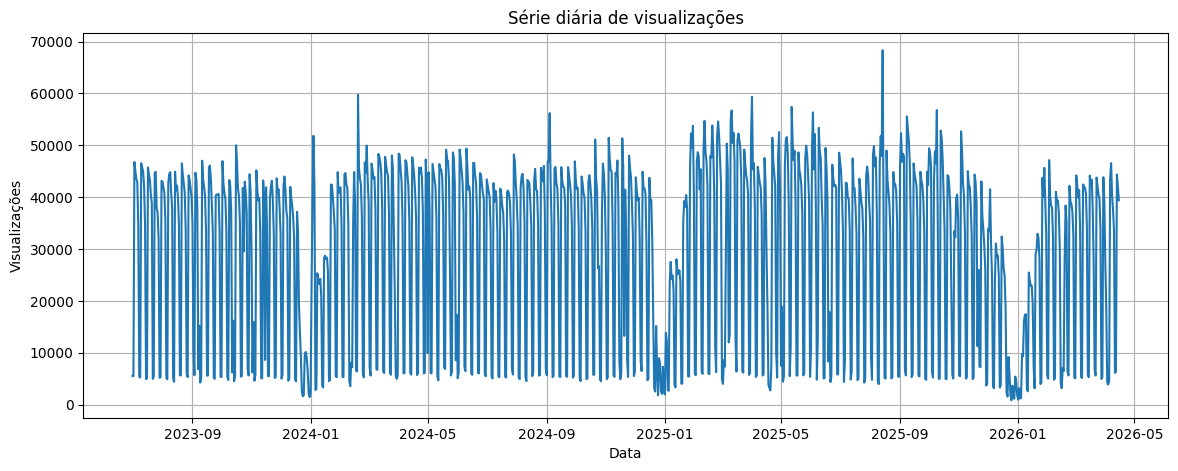

Total de observações: 1020
Treino: 816 | Teste: 204
Período de treino: 2023-07-01 a 2025-09-23
Período de teste:  2025-09-24 a 2026-04-15
d = 0 -> p-valor ADF = 0.0015
Série estacionária com d = 0.
Modelo selecionado: ARIMA(8, 0, 8) | AIC = 16728.3
OK: o melhor modelo está no interior da faixa de busca.
                               SARIMAX Results                                
Dep. Variable:          Visualizações   No. Observations:                  816
Model:                 ARIMA(8, 0, 8)   Log Likelihood               -8346.138
Date:                Wed, 24 Jun 2026   AIC                          16728.275
Time:                        09:34:36   BIC                          16812.955
Sample:                    07-01-2023   HQIC                         16760.775
                         - 09-23-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.

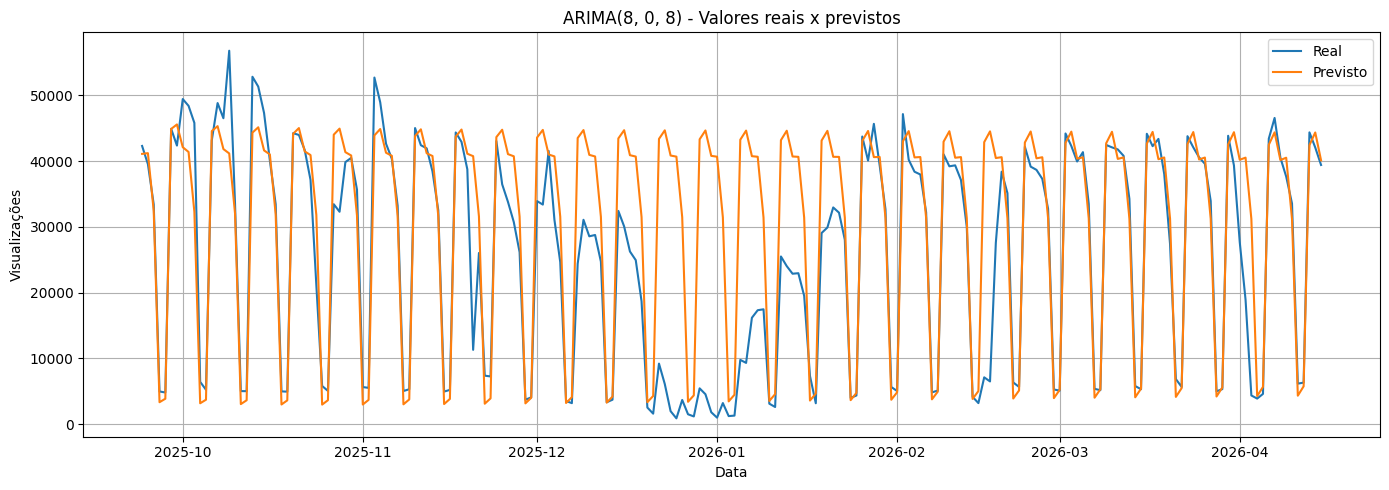

Arquivos salvos:
- ../resultados/previsao_arima.csv
- ../resultados/metricas_arima.csv
Modelo : ARIMA(8, 0, 8)
MAE    : 6,710.3 visualizações
RMSE   : 11,852.4 visualizações
R²     : 0.5022


In [1]:

# %% [markdown]
# ## 1. Importação das bibliotecas
 
# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
 
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
warnings.filterwarnings("ignore")
 
# %% [markdown]
# ## 2. Parâmetros e regras comuns do estudo
#
 
# %%
# Proporção reservada para teste (mesma para todos os modelos)
PROPORCAO_TESTE = 0.20
 
# Pastas de saída
PASTA_DADOS = "../dados"
PASTA_RESULTADOS = "../resultados"
os.makedirs(PASTA_DADOS, exist_ok=True)
os.makedirs(PASTA_RESULTADOS, exist_ok=True)
 
 
def calcular_metricas(y_real, y_previsto):
    """Métricas comuns a todos os modelos do estudo: MAE, RMSE e R².
 
    Não usamos MAPE neste trabalho. A série tem dias de volume muito baixo
    (fins de semana, feriados, recesso), e o MAPE fica distorcido nesses
    casos, deixando de ser um indicador confiável.
    """
    y_real = np.asarray(y_real, dtype=float)
    y_previsto = np.asarray(y_previsto, dtype=float)
 
    mae = mean_absolute_error(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    r2 = r2_score(y_real, y_previsto)
 
    return {"MAE": mae, "RMSE": rmse, "R2": r2}
 
 
def plotar_real_vs_previsto(datas, y_real, y_previsto, titulo_modelo, salvar_em=None):
    """Gera o gráfico padrão Real x Previsto do estudo.
 
    Use a MESMA função em todos os modelos (ARIMA, SARIMAX, SVR, Prophet),
    mudando apenas `titulo_modelo`, para que todos os gráficos saiam no mesmo
    estilo. Se `salvar_em` for informado, a figura também é salva em arquivo.
    """
    plt.figure(figsize=(14, 5))
    plt.plot(datas, y_real, label="Real")
    plt.plot(datas, y_previsto, label="Previsto")
    plt.title(f"{titulo_modelo} - Valores reais x previstos")
    plt.xlabel("Data")
    plt.ylabel("Visualizações")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
 
    if salvar_em is not None:
        plt.savefig(salvar_em, dpi=150, bbox_inches="tight")
 
    plt.show()
 
# %% [markdown]
# ## 3. Carregamento da base e montagem da série univariada
#
# A base tratada geral contém várias colunas (sessões, usuários, variáveis
# de calendário etc.). O ARIMA usa apenas a data e a variável-alvo
# `Visualizações`, porque ele não trabalha com variáveis explicativas.
 
# %%
df = pd.read_csv(f"{PASTA_DADOS}/trafego_tratado.csv")
 
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data")
 
# Série univariada: apenas data e alvo
df_arima = df[["Data", "Visualizações"]].copy()
df_arima.to_csv(f"{PASTA_DADOS}/trafego_arima_visualizacoes.csv", index=False)
 
# Define a data como índice e fixa a frequência diária
serie = df_arima.set_index("Data").asfreq("D")
serie.head()
 
# %% [markdown]
# ## 4. Verificação de continuidade da série
#
# O ARIMA exige uma série diária contínua, sem datas faltando. Se houver
# buracos no calendário, o `asfreq("D")` cria valores ausentes (NaN). A
# verificação abaixo interrompe a execução caso isso aconteça, para evitar
# resultados silenciosamente errados.
 
# %%
n_ausentes = int(serie["Visualizações"].isna().sum())
print("Valores ausentes após reindexação diária:", n_ausentes)
 
assert n_ausentes == 0, (
    "Há datas faltando na série. Trate os valores ausentes antes de prosseguir "
    "(por exemplo, com interpolação) para que o ARIMA funcione corretamente."
)
 
# %% [markdown]
# ## 5. Visualização inicial da série
#
# Antes de modelar, observamos o comportamento geral dos acessos: tendência,
# repetição semanal e quedas em fins de semana, feriados e recesso.
 
# %%
plt.figure(figsize=(14, 5))
plt.plot(serie.index, serie["Visualizações"])
plt.title("Série diária de visualizações")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.grid(True)
plt.show()
 
# %% [markdown]
# ## 6. Divisão entre treino e teste
#
# A divisão é sequencial (sem embaralhar): os dados mais antigos treinam o
# modelo e os mais recentes servem para avaliá-lo. Em séries temporais não
# se pode usar o futuro para treinar. Esta regra é a mesma para todos os
# modelos do estudo.
 
# %%
tamanho_treino = int(len(serie) * (1 - PROPORCAO_TESTE))
 
treino = serie.iloc[:tamanho_treino]
teste = serie.iloc[tamanho_treino:]
 
print("Total de observações:", len(serie))
print("Treino:", len(treino), "| Teste:", len(teste))
print("Período de treino:", treino.index.min().date(), "a", treino.index.max().date())
print("Período de teste: ", teste.index.min().date(), "a", teste.index.max().date())
 
# %% [markdown]
# ## 7. Teste de estacionariedade e definição de d
#
# O ARIMA pressupõe que a série seja estacionária (comportamento estatístico
# estável ao longo do tempo) ou possa se tornar estacionária por diferenciação.
# Usamos o teste de Dickey-Fuller aumentado (ADF):
#
# - p-valor ≤ 0,05: há evidência de estacionariedade;
# - p-valor > 0,05: a série provavelmente não é estacionária.
#
# A função abaixo descobre automaticamente quantas diferenciações (d) são
# necessárias, testando até no máximo duas.
 
# %%
def definir_d(serie_treino, max_d=2, alpha=0.05):
    serie_atual = serie_treino.dropna().copy()
 
    for d in range(max_d + 1):
        p_valor = adfuller(serie_atual)[1]
        print(f"d = {d} -> p-valor ADF = {p_valor:.4f}")
 
        if p_valor <= alpha:
            print(f"Série estacionária com d = {d}.")
            return d
 
        serie_atual = serie_atual.diff().dropna()
 
    print(f"Não foi atingida estacionariedade; adotando d = {max_d}.")
    return max_d
 
 
d = definir_d(treino["Visualizações"])
 
# %% [markdown]
# ## 8. Busca da configuração (p, q) pelo menor AIC
#
# Com o d definido, testamos várias combinações dos parâmetros p (parte
# autorregressiva) e q (média móvel). Para cada combinação, calculamos o AIC,
# um indicador que premia o bom ajuste e penaliza modelos complexos demais:
# quanto menor o AIC, melhor o equilíbrio entre qualidade e simplicidade.
#
# A faixa de busca vai de 0 a 10. Esse limite tem motivo: o padrão mais forte
# da série é o ciclo semanal (7 dias), então ordens em torno de 7 a 10 são
# suficientes para captá-lo. A busca usa apenas os dados de treino — o
# conjunto de teste não é consultado nesta etapa.
#
# Observação: esta busca testa 121 modelos e pode levar 1 a 2 minutos.
 
# %%
P_MAX = 10
Q_MAX = 10
 
resultados = []
for p in range(P_MAX + 1):
    for q in range(Q_MAX + 1):
        try:
            modelo = ARIMA(treino["Visualizações"], order=(p, d, q)).fit()
            resultados.append({"p": p, "d": d, "q": q, "AIC": modelo.aic})
        except Exception:
            continue
 
resultados_arima = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)
resultados_arima.head(10)
 
# %% [markdown]
# ## 9. Seleção do modelo e checagem da borda
#
# Selecionamos a combinação de menor AIC. O código também avisa caso o melhor
# modelo caia no limite da faixa testada (p ou q iguais ao máximo). Se isso
# acontecer, é sinal de que a faixa deveria ser ampliada, pois talvez existam
# modelos melhores além do limite. Quando o melhor fica no interior da faixa,
# temos evidência de que a busca foi suficientemente ampla.
 
# %%
melhor = resultados_arima.iloc[0]
p, d, q = int(melhor["p"]), int(melhor["d"]), int(melhor["q"])
 
print(f"Modelo selecionado: ARIMA({p}, {d}, {q}) | AIC = {melhor['AIC']:.1f}")
 
if p == P_MAX or q == Q_MAX:
    print("ATENÇÃO: o melhor modelo está no limite da faixa de busca. "
          "Considere aumentar P_MAX/Q_MAX.")
else:
    print("OK: o melhor modelo está no interior da faixa de busca.")
 
# %% [markdown]
# ## 10. Ajuste do modelo final
 
# %%
modelo_arima = ARIMA(treino["Visualizações"], order=(p, d, q)).fit()
print(modelo_arima.summary())
 
# %% [markdown]
# ## 11. Previsão no conjunto de teste
#
# O modelo prevê todo o período de teste de uma só vez, a partir do fim do
# treino. Esse é o mesmo protocolo de previsão usado nos demais modelos.
 
# %%
previsao = modelo_arima.get_forecast(steps=len(teste))
y_pred = previsao.predicted_mean
intervalo = previsao.conf_int()
 
y_pred.index = teste.index
intervalo.index = teste.index
 
df_previsao = pd.DataFrame({
    "Data": teste.index,
    "Real": teste["Visualizações"].values,
    "Previsto": y_pred.values,
    "Limite_inferior": intervalo.iloc[:, 0].values,
    "Limite_superior": intervalo.iloc[:, 1].values,
})
df_previsao.head()
 
# %% [markdown]
# ## 12. Avaliação do desempenho
#
# Usamos as três métricas comuns do estudo:
#
# - MAE: erro médio em número de visualizações;
# - RMSE: parecido com o MAE, mas penaliza mais os erros grandes;
# - R²: o quanto o modelo explica a variação da série (1 = perfeito, 0 = não
#   melhor que prever sempre a média).
 
# %%
metricas = calcular_metricas(df_previsao["Real"], df_previsao["Previsto"])
 
metricas_arima = pd.DataFrame([{
    "Modelo": "ARIMA",
    "Configuracao": f"({p}, {d}, {q})",
    "MAE": metricas["MAE"],
    "RMSE": metricas["RMSE"],
    "R2": metricas["R2"],
}])
metricas_arima


 
# %% [markdown]
# ## 13. Comparação visual entre valores reais e previstos
#
# O gráfico usa a função comum `plotar_real_vs_previsto`. Para os outros
# modelos, basta chamar a mesma função trocando o título e os dados, mantendo
# o mesmo estilo visual em todo o estudo. A figura também é salva em arquivo.
 
# %%
plotar_real_vs_previsto(
    df_previsao["Data"],
    df_previsao["Real"],
    df_previsao["Previsto"],
    titulo_modelo=f"ARIMA{(p, d, q)}",
    salvar_em=f"{PASTA_RESULTADOS}/grafico_arima.png",
)
 
# %% [markdown]
# ## 14. Salvamento dos resultados
#
# Previsões e métricas são salvas na pasta de resultados, no mesmo formato
# usado pelos outros modelos (mesmas colunas), para que o notebook de
# comparação possa juntar tudo automaticamente.
 
# %%
df_previsao.to_csv(f"{PASTA_RESULTADOS}/previsao_arima.csv", index=False)
metricas_arima.to_csv(f"{PASTA_RESULTADOS}/metricas_arima.csv", index=False)
 
print("Arquivos salvos:")
print(f"- {PASTA_RESULTADOS}/previsao_arima.csv")
print(f"- {PASTA_RESULTADOS}/metricas_arima.csv")
 
# %% [markdown]
# ## 15. Síntese
#
# O ARIMA foi aplicado à série diária de visualizações usando apenas o
# histórico da própria variável. A configuração foi escolhida pelo menor AIC,
# dentro de uma faixa de busca ampla o bastante para o melhor modelo ficar no
# interior dela (e não no limite).
#
# O modelo capta a repetição semanal nos primeiros dias de previsão, mas perde
# precisão ao longo do horizonte, aproximando-se do nível médio da série. Isso
# é esperado em um modelo univariado: sem variáveis de calendário (feriados,
# recesso, fins de semana), ele não consegue antecipar os dias atípicos mais
# distantes. Por isso, o ARIMA serve como piso de comparação para os modelos
# que usam variáveis explicativas.

# %% [markdown]
# ## 16 Exibição das métricas

# %%
print(f"Modelo : ARIMA({p}, {d}, {q})")
print(f"MAE    : {metricas['MAE']:,.1f} visualizações")
print(f"RMSE   : {metricas['RMSE']:,.1f} visualizações")
print(f"R²     : {metricas['R2']:.4f}")